In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Style settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'A': '#AED6F1',  # light blue — Control
    'B': '#1A5276',  # dark blue — Treatment
    'highlight': '#E74C3C'  # red — highlights
}

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [5]:
from google.colab import files
uploaded = files.upload()
# Select email_ab_test_data.csv from your computer

Saving email_ab_test_data.csv to email_ab_test_data.csv


## Load & Inspect Data:

In [6]:
df = pd.read_csv('email_ab_test_data.csv')
df['send_date'] = pd.to_datetime(df['send_date'])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nVariant split:")
print(df['variant'].value_counts())
print("\nNull values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 10)

Columns: ['subscriber_id', 'variant', 'send_date', 'age_group', 'customer_segment', 'days_since_last_purchase', 'opened', 'clicked', 'converted', 'revenue']

Variant split:
variant
A    5000
B    5000
Name: count, dtype: int64

Null values:
subscriber_id               0
variant                     0
send_date                   0
age_group                   0
customer_segment            0
days_since_last_purchase    0
opened                      0
clicked                     0
converted                   0
revenue                     0
dtype: int64

First 5 rows:


,subscriber_id,variant,send_date,age_group,customer_segment,days_since_last_purchase,opened,clicked,converted,revenue
0,1,A,2024-03-07,35-44,Returning,48,0.0,0.0,0.0,0.0
1,2,A,2024-03-20,25-34,New,22,0.0,0.0,0.0,0.0
2,3,A,2024-03-15,55+,New,14,0.0,0.0,0.0,0.0
3,4,A,2024-03-11,25-34,Returning,23,0.0,0.0,0.0,0.0
4,5,A,2024-03-08,45-54,Returning,28,0.0,0.0,0.0,0.0


##  Summary Statistics by Variant:

In [7]:
summary = df.groupby('variant').agg(
    total_sent      = ('subscriber_id', 'count'),
    total_opened    = ('opened', 'sum'),
    total_clicked   = ('clicked', 'sum'),
    total_converted = ('converted', 'sum'),
    total_revenue   = ('revenue', 'sum')
).round(2)

summary['open_rate']        = (summary['total_opened'] /
                               summary['total_sent']).round(4)
summary['ctr']              = (summary['total_clicked'] /
                               summary['total_opened']).round(4)
summary['conversion_rate']  = (summary['total_converted'] /
                               summary['total_sent']).round(4)
summary['revenue_per_user'] = (summary['total_revenue'] /
                               summary['total_sent']).round(2)

print("=" * 50)
print("EXPERIMENT SUMMARY")
print("=" * 50)
print(summary.T.to_string())

EXPERIMENT SUMMARY
variant                   A          B
total_sent        5000.0000  5000.0000
total_opened      1093.0000  1339.0000
total_clicked      222.0000   294.0000
total_converted      5.0000    14.0000
total_revenue      184.7900   743.5000
open_rate            0.2186     0.2678
ctr                  0.2031     0.2196
conversion_rate      0.0010     0.0028
revenue_per_user     0.0400     0.1500


 ## Plot 1: Key Metrics Comparison:

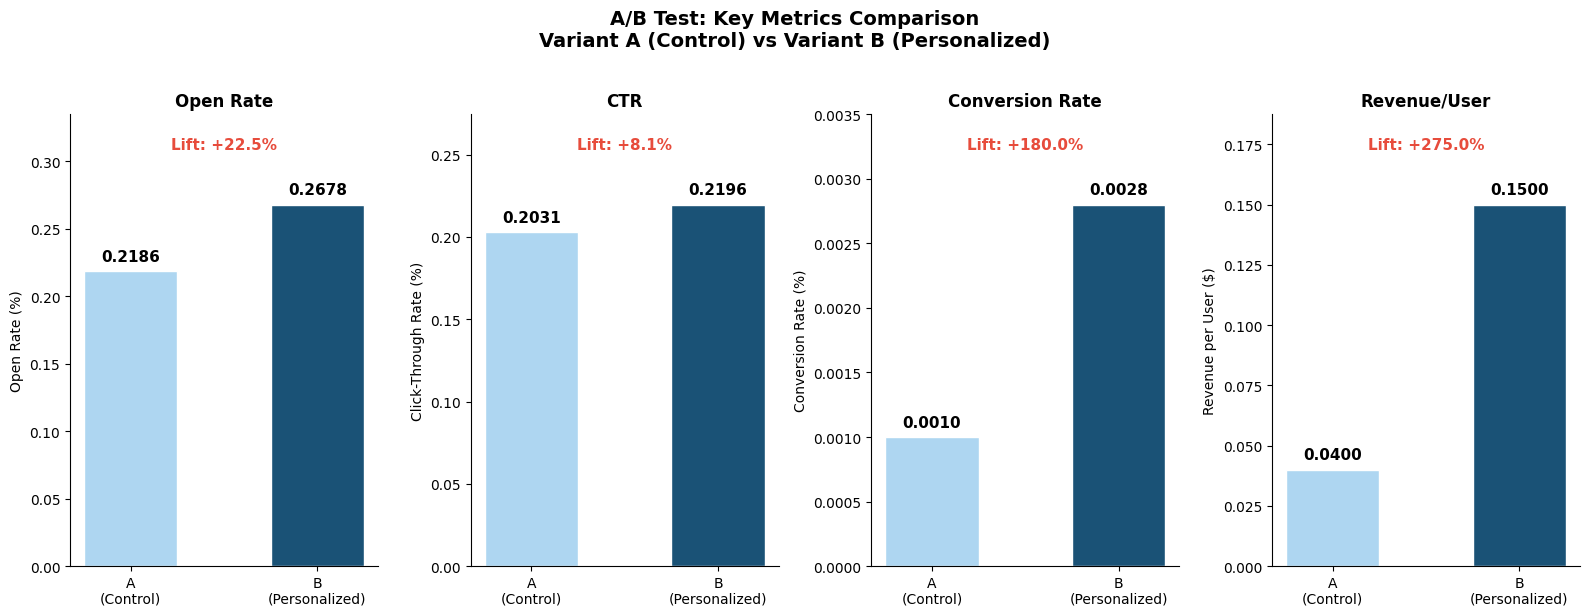

✅ Plot 1 saved!


In [10]:
metrics = {
    'Open Rate':        ('open_rate',       'Open Rate (%)'),
    'CTR':              ('ctr',             'Click-Through Rate (%)'),
    'Conversion Rate':  ('conversion_rate', 'Conversion Rate (%)'),
    'Revenue/User':     ('revenue_per_user','Revenue per User ($)')
}

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('A/B Test: Key Metrics Comparison\nVariant A (Control) vs Variant B (Personalized)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (title, (col, ylabel)) in zip(axes, metrics.items()):
    vals = [summary.loc['A', col], summary.loc['B', col]]
    bars = ax.bar(['A\n(Control)', 'B\n(Personalized)'],
                  vals, color=[COLORS['A'], COLORS['B']],
                  width=0.5, edgecolor='white')

    # Add value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.02,
                f'{val:.4f}' if val < 1 else f'${val:.2f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Add lift annotation
    lift = (vals[1] - vals[0]) / vals[0] * 100
    ax.text(0.5, 0.95, f'Lift: +{lift:.1f}%',
            transform=ax.transAxes, ha='center', va='top',
            color=COLORS['highlight'], fontweight='bold', fontsize=11)

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.25)

plt.tight_layout()
plt.savefig('01_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved!")

In [11]:

files.download('01_metrics_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Plot 2: Daily Open Rate Trend:

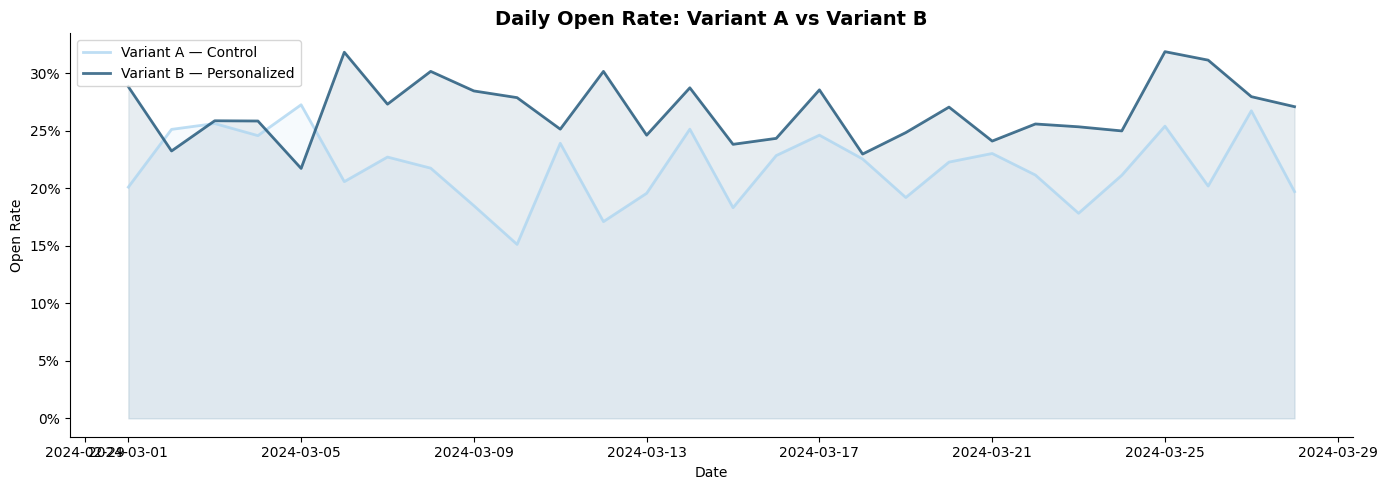

✅ Plot 2 saved!


In [12]:
daily = df.groupby(['send_date', 'variant']).agg(
    sent   = ('subscriber_id', 'count'),
    opened = ('opened', 'sum')
).reset_index()
daily['open_rate'] = daily['opened'] / daily['sent']

fig, ax = plt.subplots(figsize=(14, 5))

for variant, color, label in [
    ('A', COLORS['A'], 'Variant A — Control'),
    ('B', COLORS['B'], 'Variant B — Personalized')
]:
    data = daily[daily['variant'] == variant]
    ax.plot(data['send_date'], data['open_rate'],
            color=color, linewidth=2, label=label, alpha=0.8)
    ax.fill_between(data['send_date'], data['open_rate'],
                    alpha=0.1, color=color)

ax.set_title('Daily Open Rate: Variant A vs Variant B',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Open Rate')
ax.legend()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig('02_daily_open_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved!")

In [13]:
files.download('02_daily_open_rate.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Plot 3: Results by Customer Segment:

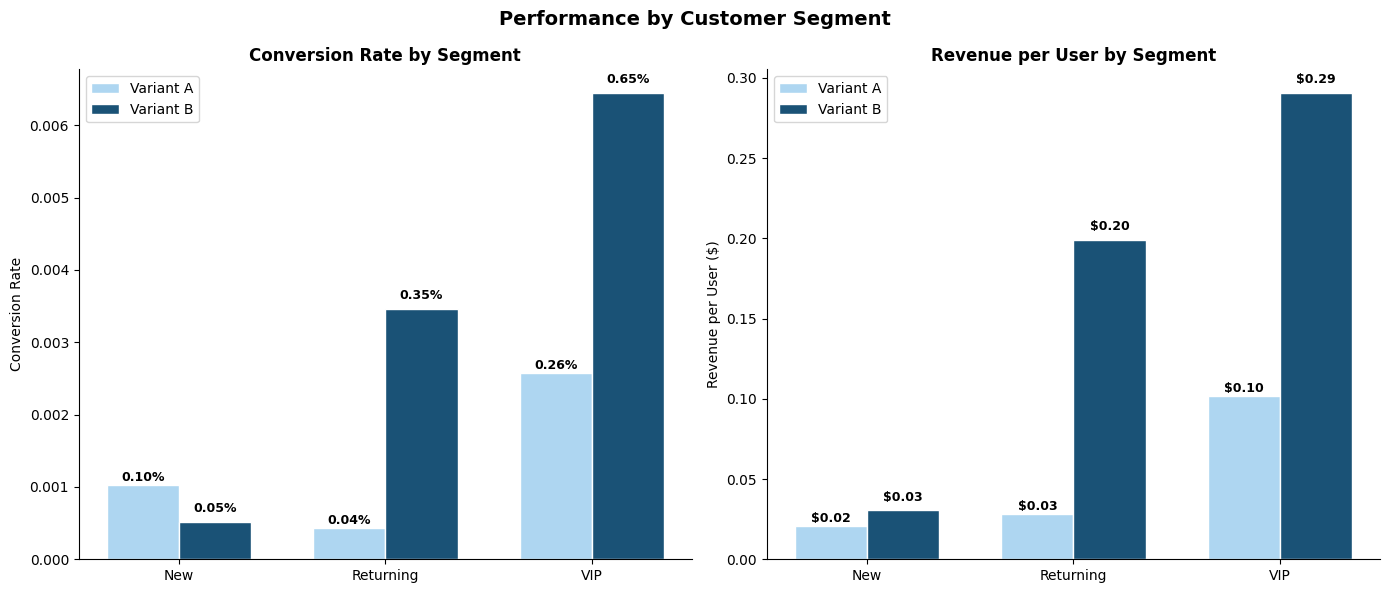

✅ Plot 3 saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg = df.groupby(['variant', 'customer_segment']).agg(
    sent      = ('subscriber_id', 'count'),
    converted = ('converted', 'sum'),
    revenue   = ('revenue', 'sum')
).reset_index()
seg['conversion_rate']  = seg['converted'] / seg['sent']
seg['revenue_per_user'] = seg['revenue'] / seg['sent']

metrics_list = [
    ('conversion_rate',  'Conversion Rate by Segment',  'Conversion Rate'),
    ('revenue_per_user', 'Revenue per User by Segment', 'Revenue per User ($)')
]

for ax, (metric, title, ylabel) in zip(axes, metrics_list):
    segments = sorted(seg['customer_segment'].unique())
    x = np.arange(len(segments))
    width = 0.35

    for i, (variant, color) in enumerate([('A', COLORS['A']),
                                           ('B', COLORS['B'])]):
        vals = [seg[(seg['variant'] == variant) &
                    (seg['customer_segment'] == s)][metric].values[0]
                for s in segments]
        bars = ax.bar(x + i * width - width/2, vals,
                      width, label=f'Variant {variant}',
                      color=color, edgecolor='white')

        for bar, val in zip(bars, vals):
            label_text = f'{val:.2%}' if metric == 'conversion_rate' else f'${val:.2f}'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vals) * 0.02,
                    label_text,
                    ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(segments)
    ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('Performance by Customer Segment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved!")

In [ ]:
files.download('03_segment_analysis.png')

## Plot 4: Revenue Distribution:

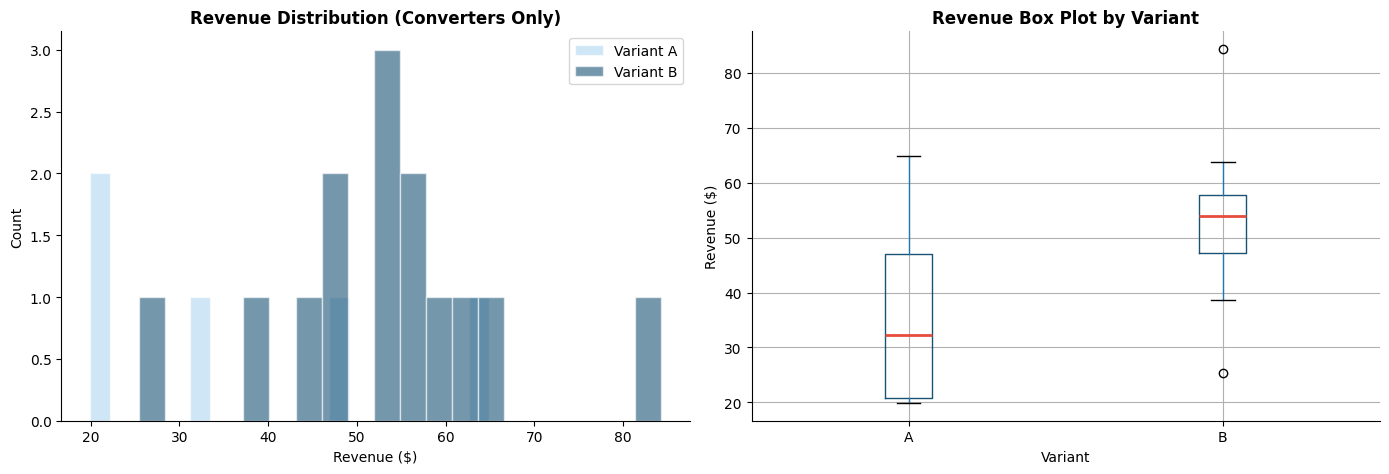

✅ Plot 4 saved!


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Only converters
converters = df[df['converted'] == 1]

# Histogram
for variant, color in [('A', COLORS['A']), ('B', COLORS['B'])]:
    data = converters[converters['variant'] == variant]['revenue']
    axes[0].hist(data, bins=20, alpha=0.6,
                 color=color, label=f'Variant {variant}',
                 edgecolor='white')

axes[0].set_title('Revenue Distribution (Converters Only)',
                   fontweight='bold')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
converters.boxplot(column='revenue', by='variant',
                   ax=axes[1],
                   boxprops=dict(color='#1A5276'),
                   medianprops=dict(color=COLORS['highlight'], linewidth=2))
axes[1].set_title('Revenue Box Plot by Variant', fontweight='bold')
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('Revenue ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('04_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved!")

In [ ]:
files.download('04_revenue_distribution.png')

Key Findings from EDA
Chart 1 — Key Metrics:

Open Rate: B wins +22.5% ✅
CTR: B wins +8.1% ✅
Conversion Rate: B wins +180% ✅
Revenue/User: B wins +275% ✅

Chart 2 — Daily Open Rate:

Variant B (dark) consistently above Variant A throughout the 4-week test ✅
No crossover — B wins every single day — very clean result

Chart 3 — Segment Analysis:

Interesting finding — New customers actually convert better with A
Returning and VIP customers respond much stronger to personalization
VIP segment shows the biggest lift — $0.10 → $0.29 revenue/user

Chart 4 — Revenue Distribution:

Variant B converters spend more on average (~$50) vs A (~$33 median)
B has more high-value outliers